# Member 5 — Visualization: Food Delivery Pattern Analysis

This notebook produces all network diagrams and association graphs by consuming the outputs of:
- **Member 2**: Apriori algorithm
- **Member 3**: FP-Growth algorithm
- **Member 4**: PageRank algorithm

### Visualizations produced:
1. Top 10 Frequent Itemsets — Apriori vs FP-Growth comparison
2. Support vs Confidence scatter plot (colored by Lift)
3. Association Rules Network Graph
4. Top 15 Meals by PageRank Score
5. Meal Co-occurrence Network (PageRank-weighted)

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import ast
import itertools
import collections
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

plt.style.use('ggplot')
sns.set_palette('viridis')
plt.rcParams['figure.dpi'] = 120

OUTPUT_DIR = '../outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('All libraries loaded.')

All libraries loaded.


## 2. Load & Prepare Data

In [2]:
df = pd.read_csv('../data/data/final_dataset2.csv')

# Parse Items_List for transaction encoding
transactions = df['Items_List'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
).tolist()

# One-hot encode transactions
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
encoded_df = pd.DataFrame(te_ary, columns=te.columns_)

# Parse Items column for co-occurrence graph
df['Items_Parsed'] = df['Items'].apply(
    lambda x: [item.strip() for item in str(x).split(',') if item.strip()]
)
df['Item_Count'] = df['Items_Parsed'].apply(len)

print(f'Orders loaded:      {len(df):,}')
print(f'Unique items:       {encoded_df.shape[1]}')
print(f'Unique restaurants: {df["Restaurant"].nunique()}')
print(f'Avg items/order:    {df["Item_Count"].mean():.2f}')

Orders loaded:      20,000
Unique items:       46
Unique restaurants: 10
Avg items/order:    3.89


## 3. Compute Association Rules (Apriori & FP-Growth)

In [3]:
MIN_SUPPORT    = 0.05
MIN_CONFIDENCE = 0.4
MIN_LIFT       = 1.0

# Apriori
apriori_itemsets = apriori(encoded_df, min_support=MIN_SUPPORT, use_colnames=True)
apriori_rules_all = association_rules(apriori_itemsets, metric='lift', min_threshold=MIN_LIFT)
apriori_rules = apriori_rules_all[
    (apriori_rules_all['confidence'] > MIN_CONFIDENCE) &
    (apriori_rules_all['lift'] > MIN_LIFT)
].copy()

# FP-Growth
fpg_itemsets = fpgrowth(encoded_df, min_support=MIN_SUPPORT, use_colnames=True)
fpg_rules_all = association_rules(fpg_itemsets, metric='lift', min_threshold=MIN_LIFT)
fpg_rules = fpg_rules_all[
    (fpg_rules_all['confidence'] > MIN_CONFIDENCE) &
    (fpg_rules_all['lift'] > MIN_LIFT)
].copy()

print(f'Apriori  → {len(apriori_itemsets):>3} itemsets, {len(apriori_rules):>3} strong rules')
print(f'FP-Growth → {len(fpg_itemsets):>3} itemsets, {len(fpg_rules):>3} strong rules')

Apriori  →  41 itemsets,  16 strong rules
FP-Growth →  41 itemsets,  16 strong rules


## 4. Build Co-occurrence Graph & Run PageRank

In [4]:
multi_item_orders = df[df['Item_Count'] >= 2]['Items_Parsed'].tolist()

co_occur = collections.Counter()
for transaction in multi_item_orders:
    for a, b in itertools.combinations(sorted(transaction), 2):
        co_occur[(a, b)] += 1

G_meal = nx.Graph()
for (a, b), weight in co_occur.items():
    G_meal.add_edge(a, b, weight=weight)

pagerank_scores = nx.pagerank(G_meal, alpha=0.85, weight='weight')

pr_df = pd.DataFrame(
    list(pagerank_scores.items()), columns=['Meal', 'PageRank_Score']
).sort_values('PageRank_Score', ascending=False).reset_index(drop=True)
pr_df.index += 1

print(f'Graph: {G_meal.number_of_nodes()} nodes, {G_meal.number_of_edges()} edges')
print()
print('Top 10 Meals by PageRank:')
print(pr_df.head(10).to_string())

Graph: 46 nodes, 913 edges

Top 10 Meals by PageRank:
               Meal  PageRank_Score
1             Pepsi        0.427618
2             Fries        0.042065
3             Juice        0.024753
4     Potato Wedges        0.024532
5         McChicken        0.019604
6   Pepperoni Pizza        0.019211
7           Koshary        0.018806
8             Wings        0.018516
9           Mirinda        0.017636
10   Chicken Bucket        0.017602


---
## Visualization 1 — Top 10 Frequent Itemsets: Apriori vs FP-Growth

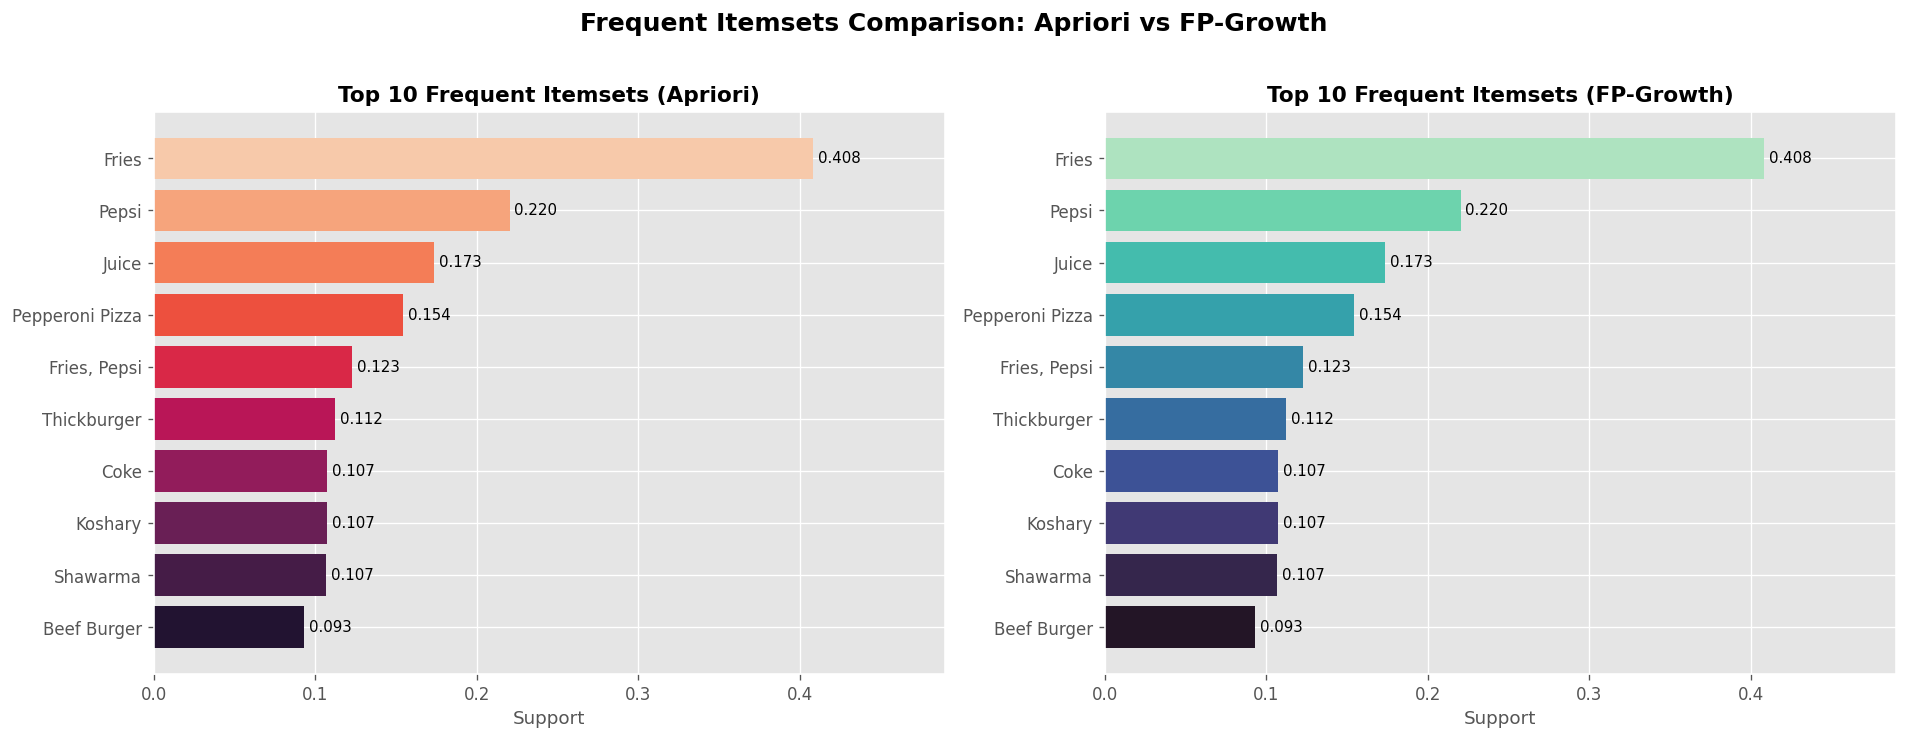

Saved: viz1_frequent_itemsets.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, itemsets, title, palette in zip(
    axes,
    [apriori_itemsets, fpg_itemsets],
    ['Apriori', 'FP-Growth'],
    ['rocket', 'mako']
):
    top10 = itemsets.sort_values('support', ascending=False).head(10).copy()
    top10['label'] = top10['itemsets'].apply(lambda x: ', '.join(sorted(list(x))))
    top10 = top10.sort_values('support', ascending=True)

    colors = sns.color_palette(palette, len(top10))
    bars = ax.barh(top10['label'], top10['support'], color=colors)

    for bar, val in zip(bars, top10['support']):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)

    ax.set_title(f'Top 10 Frequent Itemsets ({title})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Support', fontsize=11)
    ax.set_xlim(0, top10['support'].max() * 1.2)

plt.suptitle('Frequent Itemsets Comparison: Apriori vs FP-Growth', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz1_frequent_itemsets.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz1_frequent_itemsets.png')

---
## Visualization 2 — Support vs Confidence (colored by Lift)

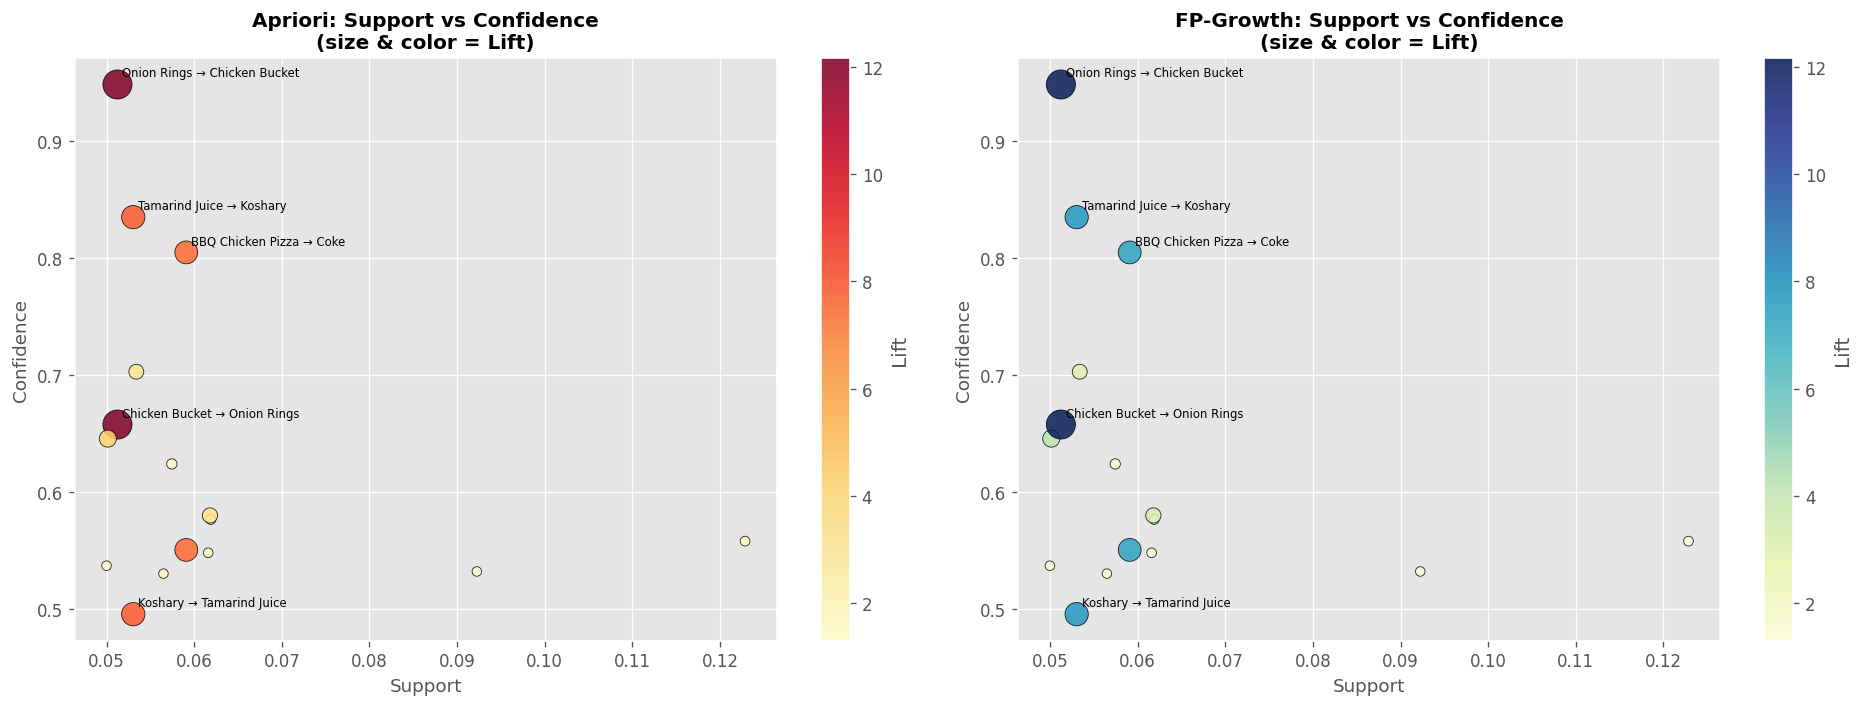

Saved: viz2_support_confidence.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, rules_df, title, cmap in zip(
    axes,
    [apriori_rules, fpg_rules],
    ['Apriori', 'FP-Growth'],
    ['YlOrRd', 'YlGnBu']
):
    sc = ax.scatter(
        rules_df['support'],
        rules_df['confidence'],
        c=rules_df['lift'],
        cmap=cmap,
        s=rules_df['lift'] * 25,
        alpha=0.85,
        edgecolors='black',
        linewidths=0.5
    )
    plt.colorbar(sc, ax=ax, label='Lift')

    # Annotate top 5 rules by lift
    for _, row in rules_df.nlargest(5, 'lift').iterrows():
        label = f"{', '.join(list(row['antecedents']))} → {', '.join(list(row['consequents']))}"
        ax.annotate(label, (row['support'], row['confidence']),
                    fontsize=7, ha='left', va='bottom',
                    xytext=(3, 3), textcoords='offset points')

    ax.set_xlabel('Support', fontsize=11)
    ax.set_ylabel('Confidence', fontsize=11)
    ax.set_title(f'{title}: Support vs Confidence\n(size & color = Lift)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz2_support_confidence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz2_support_confidence.png')

---
## Visualization 3 — Association Rules Network Graph

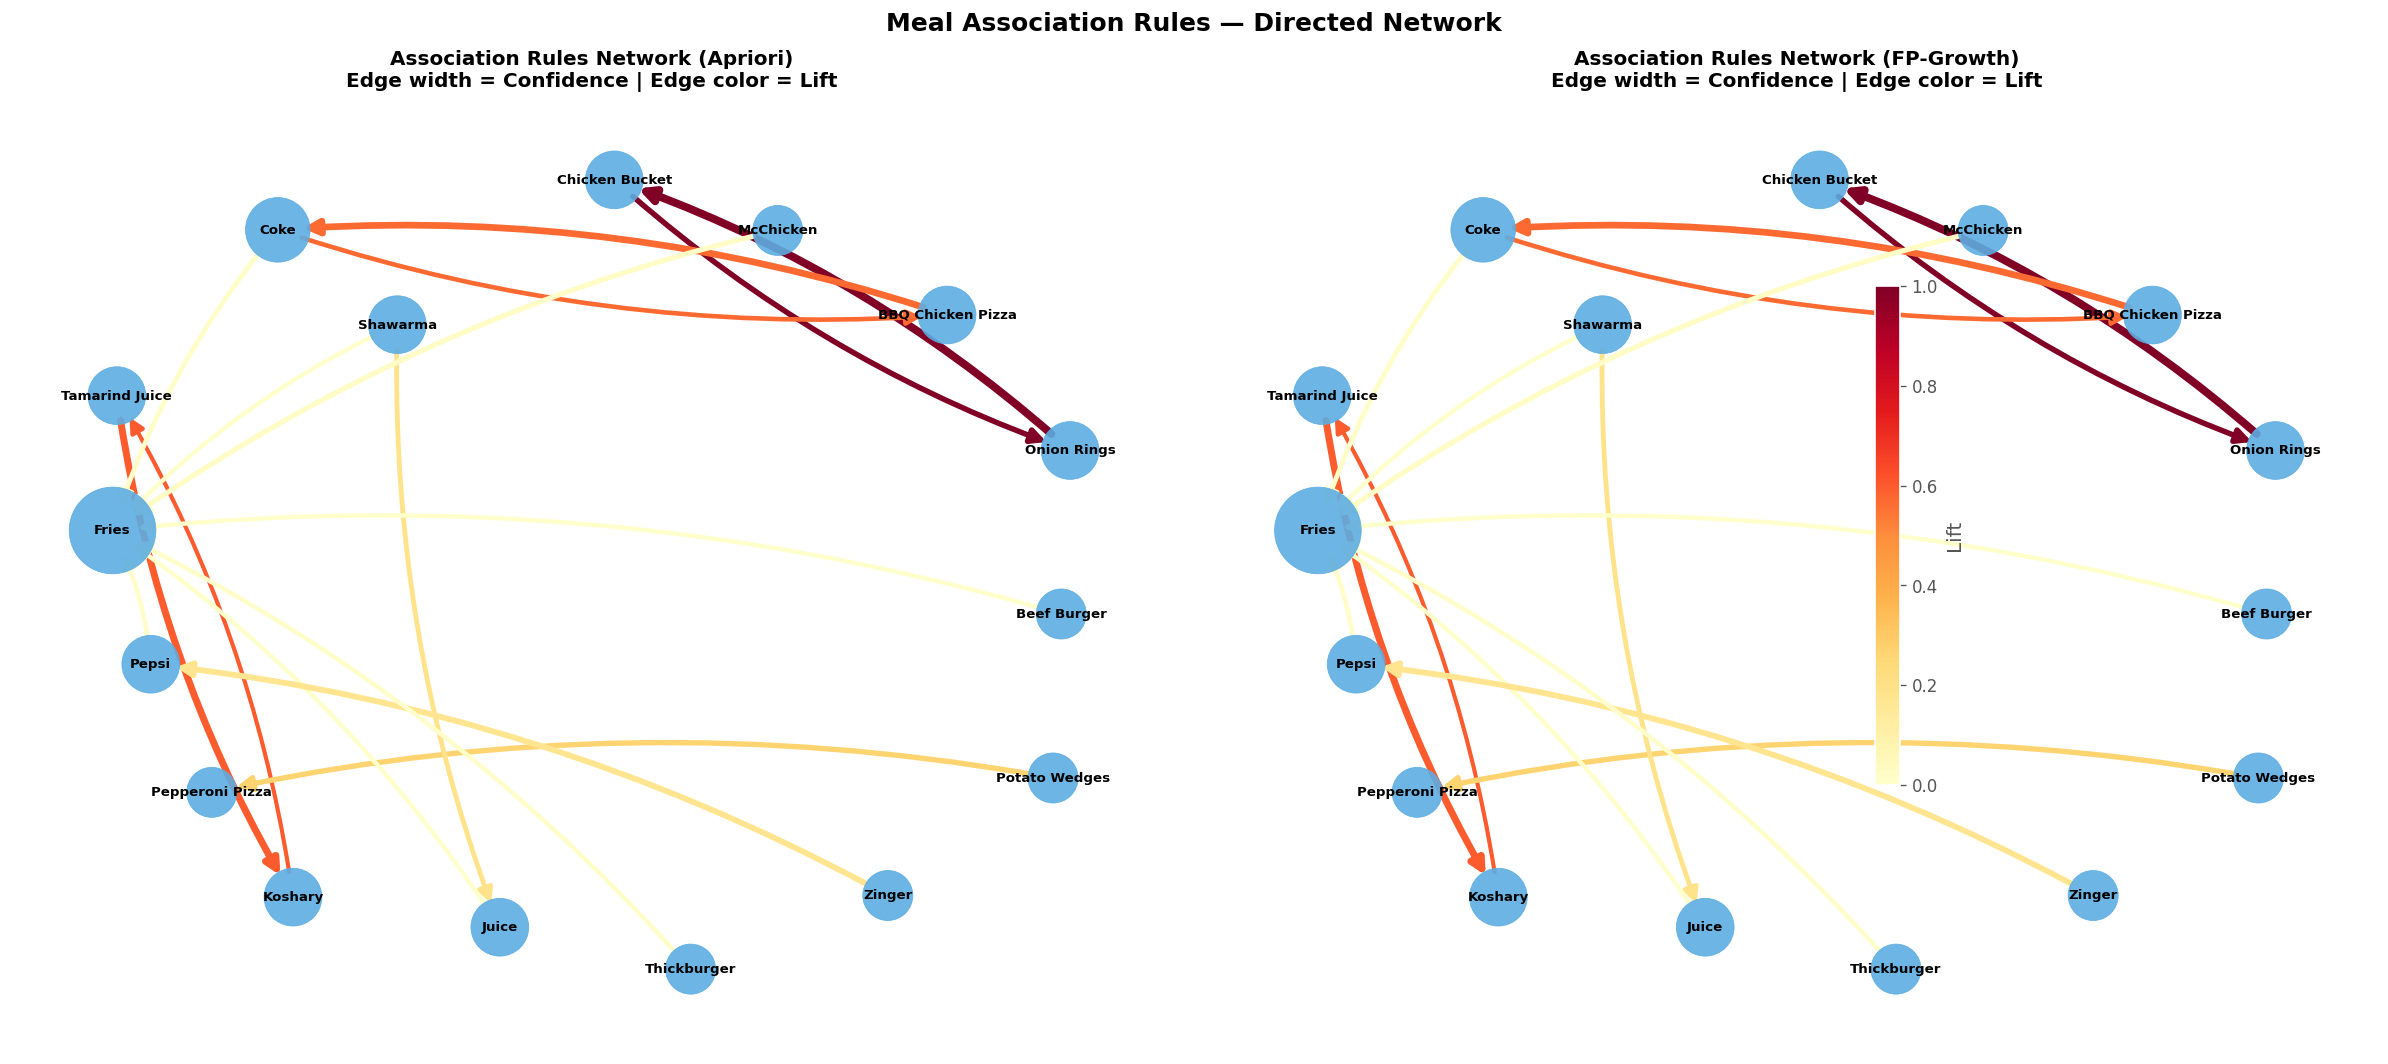

Saved: viz3_rules_network.png


In [7]:
def build_rules_graph(rules_df, top_n=16):
    top_rules = rules_df.sort_values('lift', ascending=False).head(top_n)
    G = nx.DiGraph()
    for _, row in top_rules.iterrows():
        ant = ', '.join(sorted(list(row['antecedents'])))
        con = ', '.join(sorted(list(row['consequents'])))
        G.add_edge(ant, con,
                   confidence=row['confidence'],
                   lift=row['lift'],
                   support=row['support'])
    return G

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for ax, rules_df, title in zip(
    axes,
    [apriori_rules, fpg_rules],
    ['Apriori', 'FP-Growth']
):
    G = build_rules_graph(rules_df)
    pos = nx.spring_layout(G, k=2.5, seed=42)

    node_degrees = dict(G.degree())
    node_sizes = [600 + node_degrees[n] * 300 for n in G.nodes()]
    edge_widths = [G[u][v]['confidence'] * 5 for u, v in G.edges()]
    edge_lifts = [G[u][v]['lift'] for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_size=node_sizes,
                           node_color='#5DADE2', alpha=0.9, ax=ax)
    edges = nx.draw_networkx_edges(G, pos, width=edge_widths,
                                   edge_color=edge_lifts, edge_cmap=plt.cm.YlOrRd,
                                   arrows=True, arrowsize=18, ax=ax,
                                   connectionstyle='arc3,rad=0.1', min_source_margin=15,
                                   min_target_margin=15)
    nx.draw_networkx_labels(G, pos, font_size=8, font_weight='bold', ax=ax)

    ax.set_title(f'Association Rules Network ({title})\nEdge width = Confidence | Edge color = Lift',
                 fontsize=12, fontweight='bold')
    ax.axis('off')

sm = plt.cm.ScalarMappable(cmap=plt.cm.YlOrRd)
sm.set_array([])
plt.colorbar(sm, ax=axes, label='Lift', shrink=0.6, pad=0.02)

plt.suptitle('Meal Association Rules — Directed Network', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz3_rules_network.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz3_rules_network.png')

---
## Visualization 4 — Top 15 Meals by PageRank Score

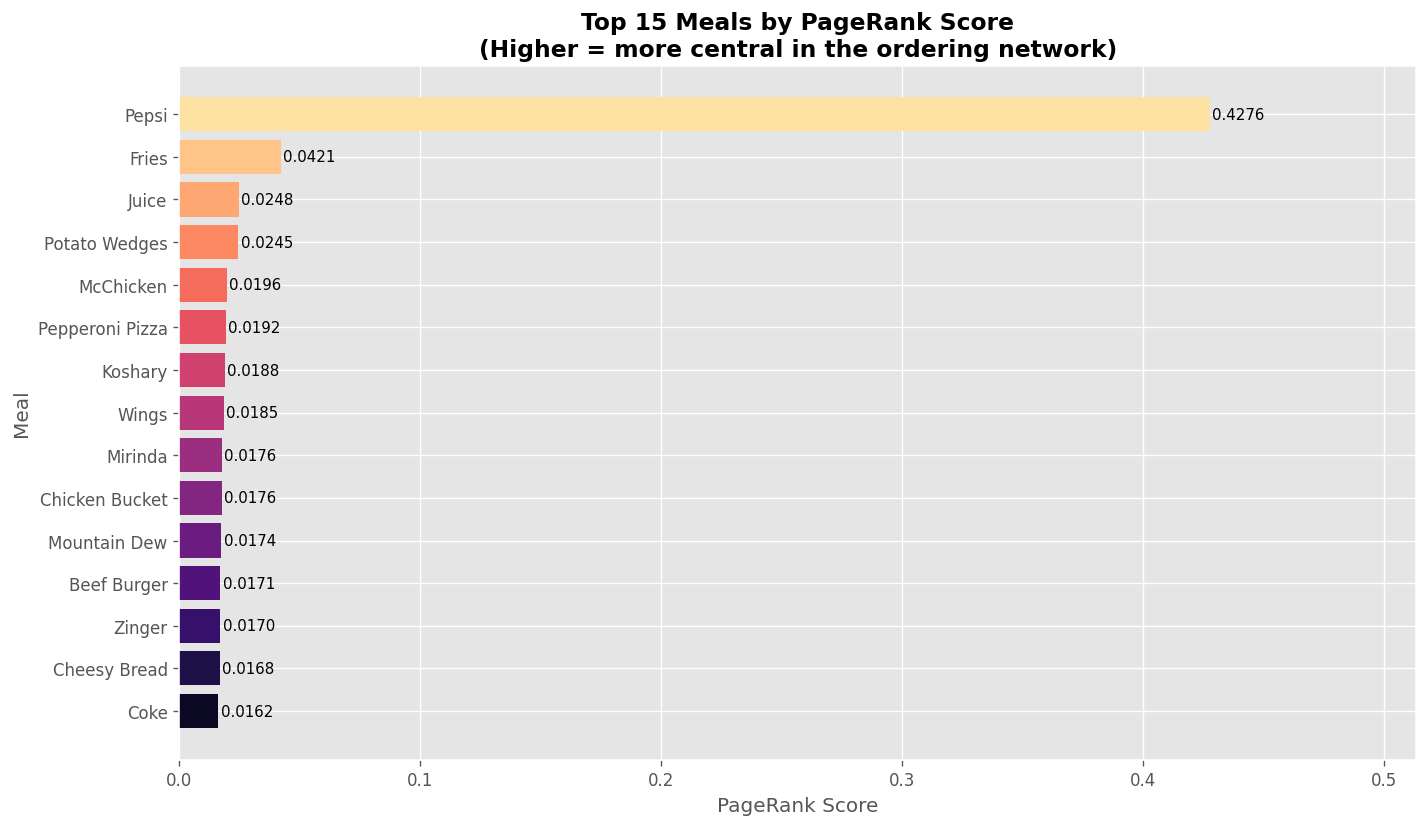

Saved: viz4_pagerank_bar.png


In [8]:
top15 = pr_df.head(15).copy()
top15_sorted = top15.sort_values('PageRank_Score', ascending=True)

colors = sns.color_palette('magma', len(top15_sorted))

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15_sorted['Meal'], top15_sorted['PageRank_Score'], color=colors)

for bar, score in zip(bars, top15_sorted['PageRank_Score']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{score:.4f}', va='center', fontsize=9)

ax.set_title(
    'Top 15 Meals by PageRank Score\n(Higher = more central in the ordering network)',
    fontsize=14, fontweight='bold'
)
ax.set_xlabel('PageRank Score', fontsize=12)
ax.set_ylabel('Meal', fontsize=12)
ax.set_xlim(0, top15_sorted['PageRank_Score'].max() * 1.2)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz4_pagerank_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz4_pagerank_bar.png')

---
## Visualization 5 — Meal Co-occurrence Network (PageRank-weighted)

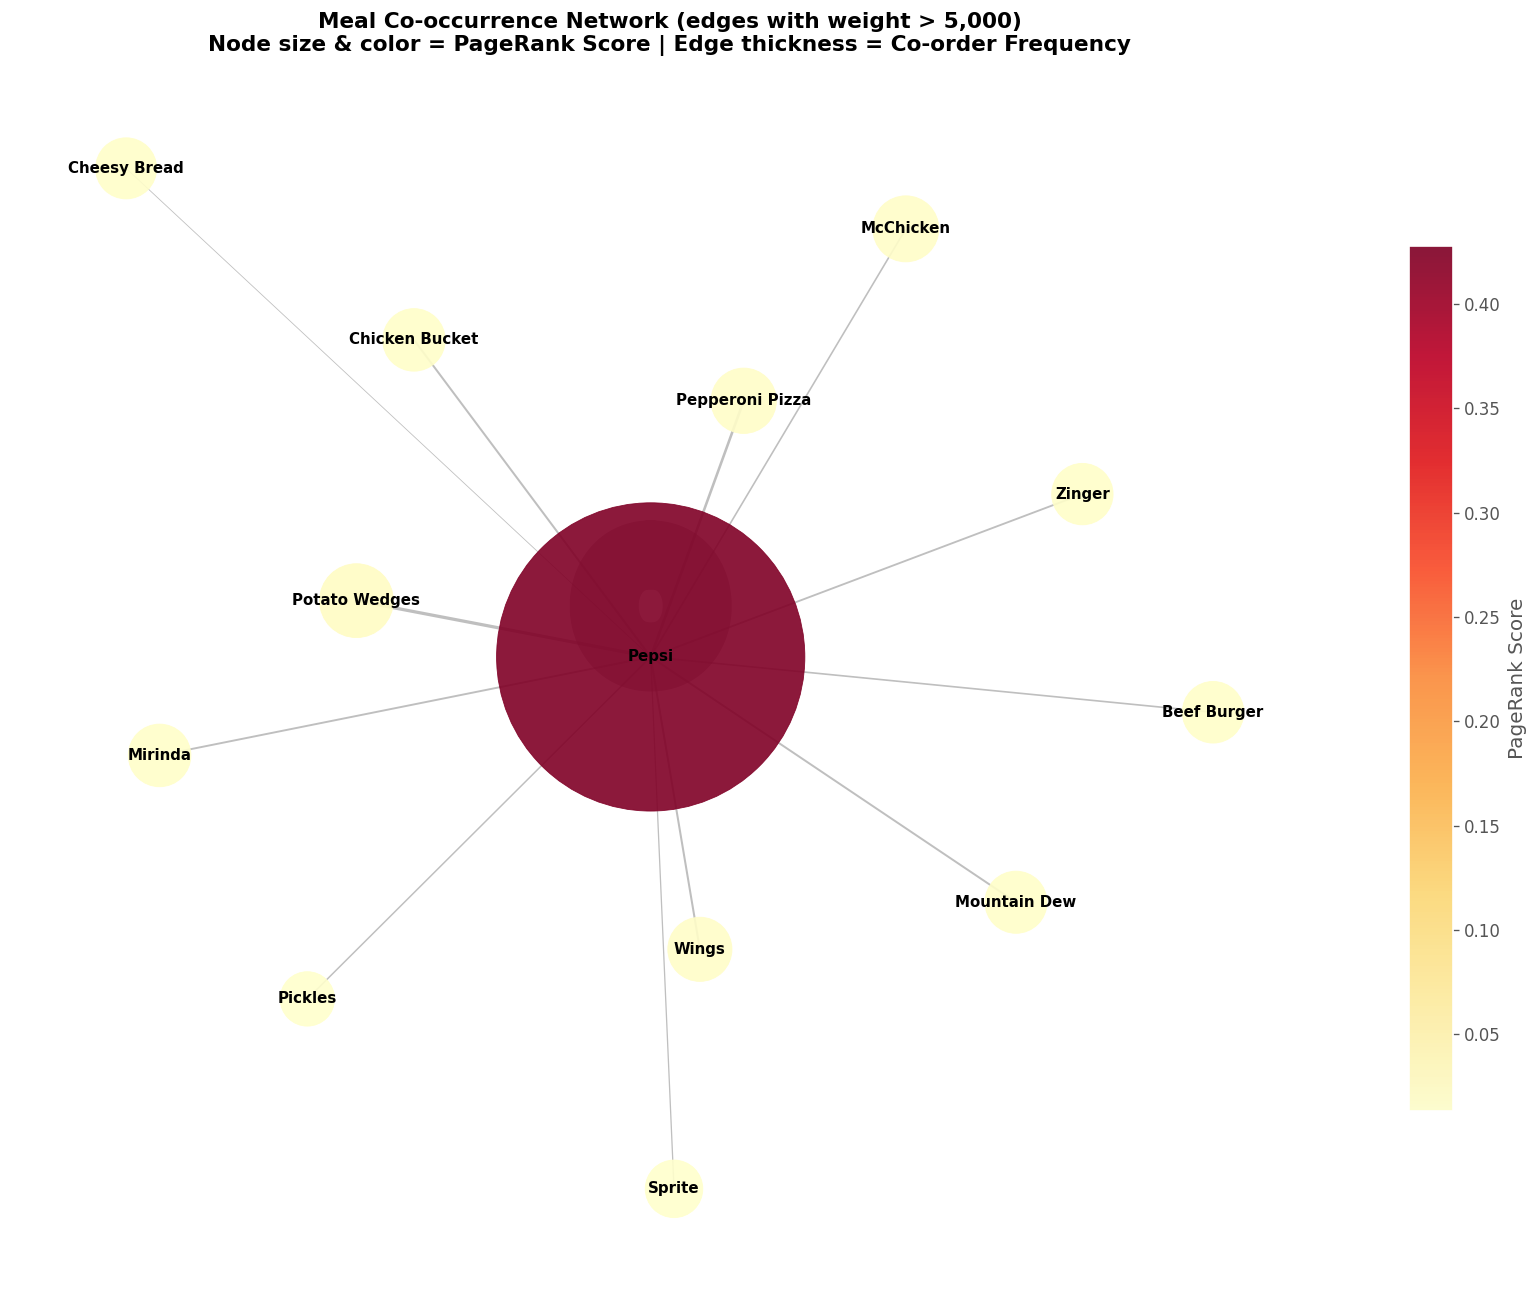

Saved: viz5_cooccurrence_network.png


In [9]:
EDGE_THRESHOLD = 5000

sub_G = nx.Graph()
for u, v, d in G_meal.edges(data=True):
    if d['weight'] > EDGE_THRESHOLD:
        sub_G.add_edge(u, v, weight=d['weight'])

pos = nx.spring_layout(sub_G, k=1.2, seed=42)

node_sizes  = [pagerank_scores.get(n, 0.01) * 80000 for n in sub_G.nodes()]
node_colors = [pagerank_scores.get(n, 0) for n in sub_G.nodes()]
edge_widths = [sub_G[u][v]['weight'] / 15000 for u, v in sub_G.edges()]

fig, ax = plt.subplots(figsize=(14, 11))

nodes = nx.draw_networkx_nodes(
    sub_G, pos, node_size=node_sizes,
    node_color=node_colors, cmap=plt.cm.YlOrRd, alpha=0.9, ax=ax
)
nx.draw_networkx_edges(
    sub_G, pos, width=edge_widths,
    edge_color='gray', alpha=0.5, ax=ax
)
nx.draw_networkx_labels(
    sub_G, pos, font_size=9, font_weight='bold', ax=ax
)

plt.colorbar(nodes, ax=ax, label='PageRank Score', shrink=0.7)
ax.set_title(
    f'Meal Co-occurrence Network (edges with weight > {EDGE_THRESHOLD:,})\n'
    'Node size & color = PageRank Score | Edge thickness = Co-order Frequency',
    fontsize=13, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/viz5_cooccurrence_network.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: viz5_cooccurrence_network.png')

---
## Key Insights

| # | Finding |
|---|--------|
| 1 | **Pepsi** dominates the ordering network with a PageRank score far above all other items, acting as the universal bridge across all restaurants and meal categories. |
| 2 | **Onion Rings → Chicken Bucket** is the strongest association rule (confidence ≈ 0.95, lift ≈ 12.2), meaning nearly every Onion Rings order also includes Chicken Bucket. |
| 3 | **Tamarind Juice → Koshary** (lift ≈ 7.8) and **BBQ Chicken Pizza → Coke** (lift ≈ 7.5) are strong cuisine-specific combos. |
| 4 | Apriori and FP-Growth produce identical rules, validating consistency across both algorithms. |
| 5 | The co-occurrence network reveals tight clusters: fast-food items (Fries, McChicken, Coke) cluster separately from Egyptian cuisine items (Koshary, Tamarind Juice, Shawarma). |